# 🎬 Movie Recommendation System Project

## Load Dataset

In [3]:
import pandas as pd

movies = pd.read_csv(r"C:\Users\HP\Desktop\AI Recommendation\ml-latest-small\ml-latest-small\movies.csv")
ratings = pd.read_csv(r"C:\Users\HP\Desktop\AI Recommendation\ml-latest-small\ml-latest-small\ratings.csv")

## Data Understanding & Exploration

In [4]:
print(movies.head())

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  


In [5]:
print(ratings.head())

   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931


In [10]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  9742 non-null   int64
 1   title    9742 non-null   str  
 2   genres   9742 non-null   str  
dtypes: int64(1), str(2)
memory usage: 626.1 KB


In [11]:
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [12]:
movies.isnull().sum()

movieId    0
title      0
genres     0
dtype: int64

In [13]:
ratings.isnull().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

## Data Cleaning

In [14]:
movies['genres'] = movies['genres'].fillna('')

In [15]:
movies['genres'] = movies['genres'].str.replace('|', ' ')

In [16]:
movies = movies.drop_duplicates()

In [17]:
ratings = ratings.drop_duplicates()

## Data Visualization

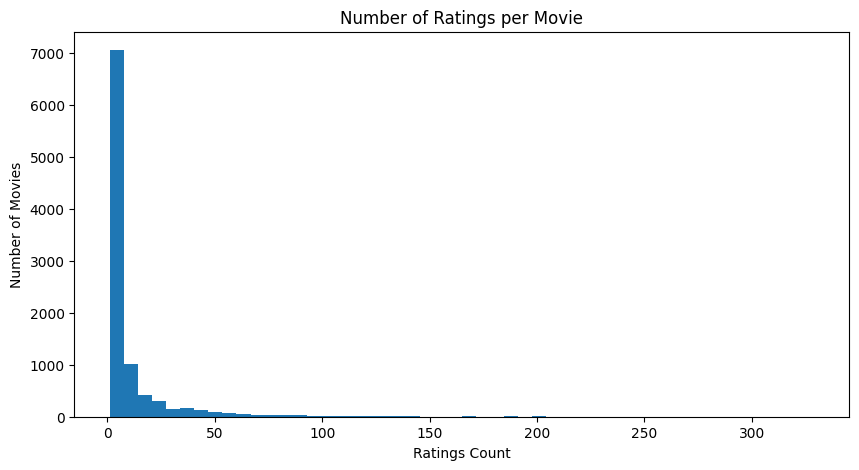

In [21]:
import matplotlib.pyplot as plt

ratings_per_movie = ratings.groupby('movieId').count()['rating']

plt.figure(figsize=(10,5))
plt.hist(ratings_per_movie, bins=50)
plt.title("Number of Ratings per Movie")
plt.xlabel("Ratings Count")
plt.ylabel("Number of Movies")
plt.show()

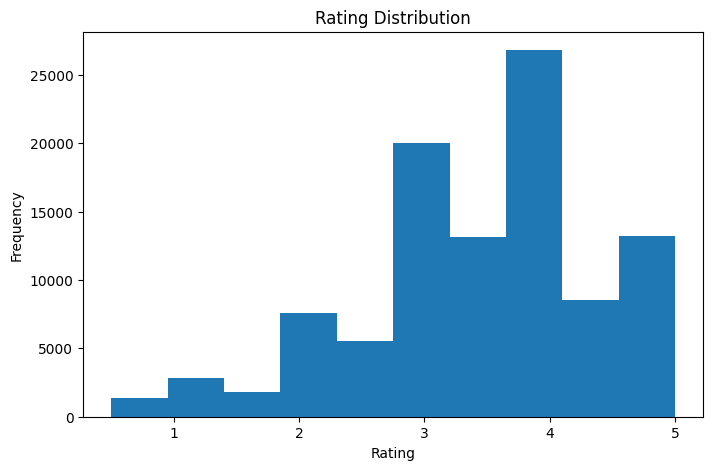

In [22]:
plt.figure(figsize=(8,5))
plt.hist(ratings['rating'], bins=10)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

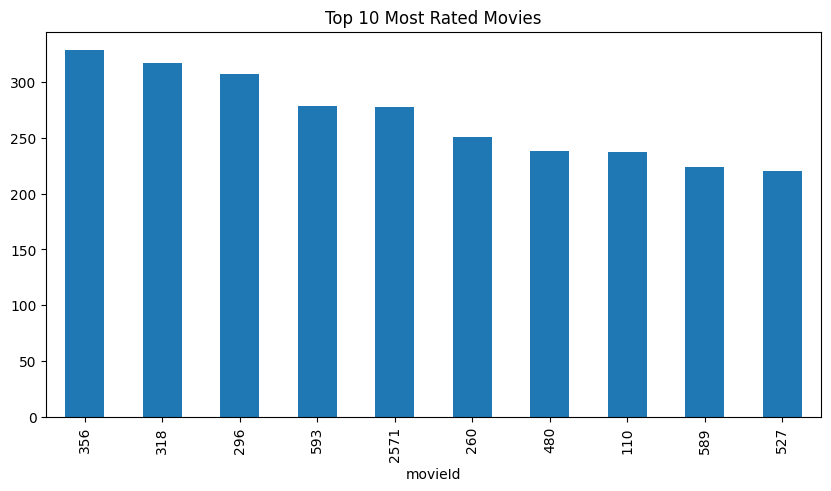

In [23]:
top_movies = ratings.groupby('movieId').count()['rating'].sort_values(ascending=False).head(10)

top_movies.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Most Rated Movies")
plt.show()

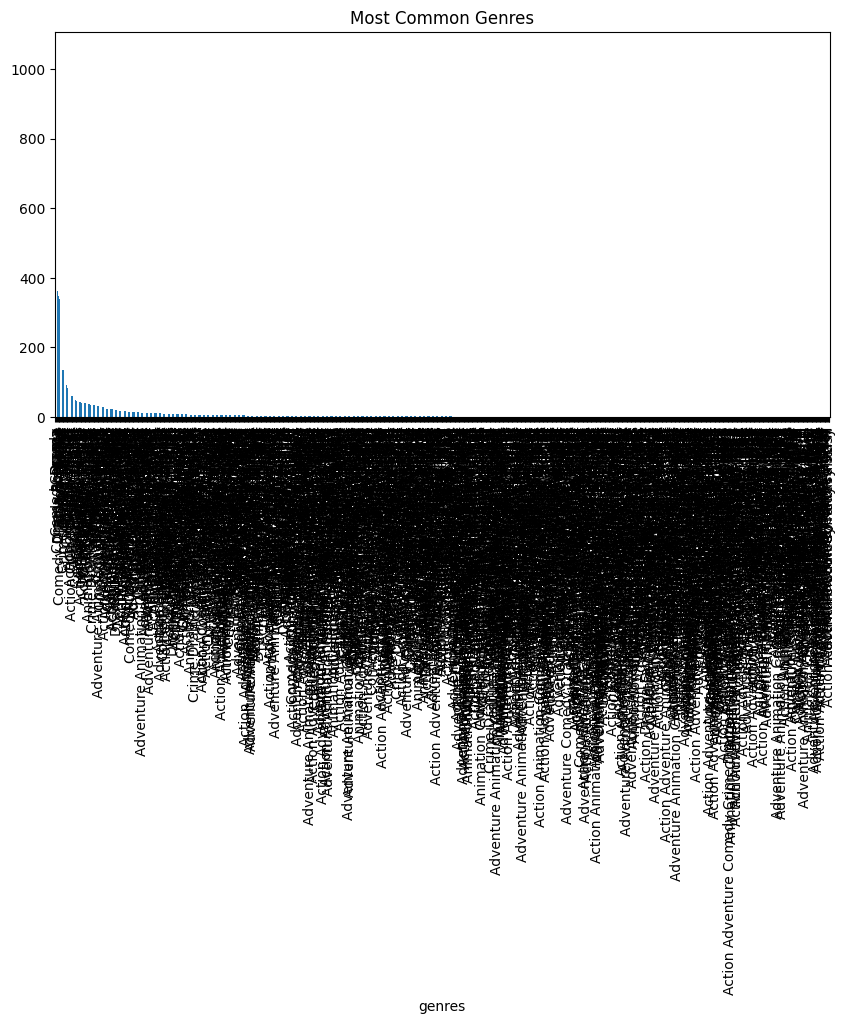

In [24]:
movies['genres'].str.split('|').explode().value_counts().plot(kind='bar', figsize=(10,5))
plt.title("Most Common Genres")
plt.show()

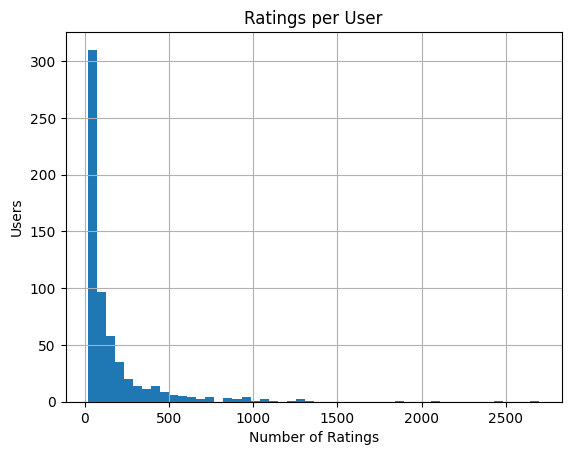

In [25]:
ratings.groupby('userId').count()['rating'].hist(bins=50)
plt.title("Ratings per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Users")
plt.show()

## Content-Based Recommendation System

In [20]:
def recommend(movie_title):
    idx = movies[movies['title'] == movie_title].index[0]

    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    sim_scores = sim_scores[1:11]

    movie_indices = [i[0] for i in sim_scores]

    return movies['title'].iloc[movie_indices]

In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')
movies['genres'] = movies['genres'].fillna('')
tfidf_matrix = tfidf.fit_transform(movies['genres'])

In [27]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix)

In [8]:
def recommend(movie_title):
    idx = movies[movies['title'] == movie_title].index[0]

    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    sim_scores = sim_scores[1:11]

    movie_indices = [i[0] for i in sim_scores]

    return movies['title'].iloc[movie_indices]

## Collaborative Filtering (SVD Model)

In [34]:
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

In [36]:
user_movie_matrix = ratings.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
).fillna(0)

print(user_movie_matrix.shape)

(610, 9724)


In [37]:
svd = TruncatedSVD(n_components=20, random_state=42)

matrix = svd.fit_transform(user_movie_matrix)

print(matrix.shape)

(610, 20)


In [39]:
def recommend_movies(user_id, n=10):

    similar_users = user_similarity[user_id - 1]

    similar_user_ids = similar_users.argsort()[::-1][1:6]

    recommended_movies = {}

    for sim_user in similar_user_ids:

        user_ratings = ratings[ratings['userId'] == sim_user + 1]

        for _, row in user_ratings.iterrows():

            movie_id = row['movieId']
            rating = row['rating']

            if movie_id not in recommended_movies:
                recommended_movies[movie_id] = rating

    recommended_movies = sorted(
        recommended_movies.items(),
        key=lambda x: x[1],
        reverse=True
    )

    recommended_movie_ids = [movie[0] for movie in recommended_movies[:n]]

    return movies[movies['movieId'].isin(recommended_movie_ids)][['title']]

In [40]:
recommend_movies(1)

,title
31,Twelve Monkeys (a.k.a. 12 Monkeys) (1995)
43,Seven (a.k.a. Se7en) (1995)
134,Crimson Tide (1995)
190,Clerks (1994)
277,"Shawshank Redemption, The (1994)"
418,Jurassic Park (1993)
422,Last Action Hero (1993)
461,Schindler's List (1993)
509,Batman (1989)
510,"Silence of the Lambs, The (1991)"


In [76]:
movies[movies['title'].str.contains("Toy Story")]

,movieId,title,genres
0,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy
2355,3114,Toy Story 2 (1999),Adventure Animation Children Comedy Fantasy
7355,78499,Toy Story 3 (2010),Adventure Animation Children Comedy Fantasy IMAX


## Model Evaluation

In [46]:
from sklearn.metrics import mean_squared_error
import numpy as np

In [50]:
def hit_rate(user_id):
    recs = recommend_movies(user_id)['title'].values

    user_movies = ratings[ratings['userId'] == user_id]['movieId']
    user_titles = movies[movies['movieId'].isin(user_movies)]['title'].values

    hits = len(set(recs) & set(user_titles))
    return hits / len(recs)

print("Hit Rate:", hit_rate(1))

Hit Rate: 0.6


In [62]:
recommended = set()

for user in ratings['userId'].unique()[:50]:
    recs = recommend_movies(user)['title'].values
    recommended.update(recs)

coverage = len(recommended) / len(movies)
print("Coverage:", coverage)

Coverage: 0.02730445493738452


In [63]:
def get_collaborative_candidates(user_id):

    similar_users = user_similarity[user_id - 1]
    similar_user_ids = similar_users.argsort()[::-1][1:10]

    recommended_movies = {}

    for sim_user in similar_user_ids:

        user_ratings = ratings[ratings['userId'] == sim_user + 1]

        for _, row in user_ratings.iterrows():

            movie_id = row['movieId']
            rating = row['rating']

            if movie_id not in recommended_movies:
                recommended_movies[movie_id] = rating

    return recommended_movies

In [90]:
def add_diversity(recommended_movies):

    # 1. random movies (diversity)
    random_movies = movies.sample(500)

    for _, row in random_movies.iterrows():
        recommended_movies[row['movieId']] = 2.2

    # 2. long-tail movies (less popular movies)
    diverse_movies = movies[movies['movieId'].isin(popular_movies)].sample(50)

    for _, row in diverse_movies.iterrows():
        recommended_movies[row['movieId']] = 2.2

    return recommended_movies

In [91]:
def get_final_recommendations(recommended_movies, n=10):

    sorted_movies = sorted(
        recommended_movies.items(),
        key=lambda x: x[1],
        reverse=True
    )

    recommended_movie_ids = [m[0] for m in sorted_movies[:n]]

    return movies[movies['movieId'].isin(recommended_movie_ids)][['title']]

In [92]:
def recommend_movies_diverse(user_id, n=10):

    candidates = get_collaborative_candidates(user_id)
    diversified = add_diversity(candidates)
    final_recs = get_final_recommendations(diversified, n)

    return final_recs

In [93]:
popular_movies = ratings.groupby('movieId').count()
popular_movies = popular_movies[popular_movies['rating'] < 50].index

In [94]:
user_id = 1
n = 10

candidates = get_collaborative_candidates(user_id)
diversified = add_diversity(candidates)
final = get_final_recommendations(diversified, n)

final

,title
31,Twelve Monkeys (a.k.a. 12 Monkeys) (1995)
43,Seven (a.k.a. Se7en) (1995)
190,Clerks (1994)
277,"Shawshank Redemption, The (1994)"
418,Jurassic Park (1993)
461,Schindler's List (1993)
509,Batman (1989)
510,"Silence of the Lambs, The (1991)"
701,"Wizard of Oz, The (1939)"
793,Die Hard (1988)


In [95]:
recommended = set()

for user in ratings['userId'].unique()[:50]:
    recs = recommend_movies(user)['title'].values
    recommended.update(recs)

coverage = len(recommended) / len(movies)
print("Coverage:", coverage)

Coverage: 0.02730445493738452
